# Breadth-First Search (BFS)

## 1. Introduction

**Breadth-First Search (BFS)** is an uninformed search algorithm that explores a graph **level by level**.

It visits all nodes at the current depth before moving to the next depth.

BFS uses a **Queue (FIFO — First In, First Out)** to manage the order of exploration.

### Key Properties

- **Type:** Uninformed Search
- **Strategy:** Level-by-level exploration
- **Data Structure:** Queue (FIFO)
- **Complete:** Yes, for finite graphs
- **Optimal:** Yes, for unweighted graphs (shortest path by number of edges)

### Learning Objectives

By the end of this notebook, you will understand:

1. How BFS explores a graph.
2. Why BFS uses a Queue.
3. How to implement BFS in Python.
4. How to track visited nodes and reconstruct paths.
5. How to analyze BFS performance.

## 2. Graph Representation

A **graph** consists of:

- **Vertices (Nodes):** Represent states or locations.
- **Edges:** Represent connections between nodes.

We will represent our graph using an **Adjacency List**, implemented as a Python dictionary.

Each key represents a node, and its corresponding list contains the nodes that can be reached directly from it.

Our example uses a **Directed Graph**, meaning connections have a specific direction.

**Search Problem:**

- Initial State: `S`
- Goal State: `G`
- Objective: Find a shortest path from `S` to `G`.

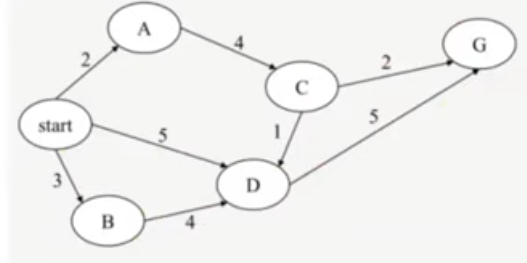

In [1]:
graph = {
    'S': ['B', 'D', 'A'],
    'A': ['C'],
    'B': ['D'],
    'C': ['G', 'D'],
    'D': ['G'],
    'G': []
}

### Understanding the Adjacency List

Consider the following entry:

```python
'S': ['B', 'D', 'A']
```

This means that node `S` has three outgoing edges:

- `S → B`
- `S → D`
- `S → A`

Similarly:

```python
'G': []
```

means that node `G` has no outgoing edges.

**Important:** The order of neighbors affects BFS exploration order, but it does not change the shortest-path guarantee for unweighted graphs.

## 3. How BFS Works

BFS explores nodes in increasing order of depth.

### Algorithm Steps

1. Create a queue containing the starting path.
2. Mark the starting node as discovered.
3. Remove the first path from the queue.
4. Check whether the last node is the goal.
5. If the goal is found, return the path.
6. Otherwise, explore its unvisited neighbors.
7. Add a new path for each unvisited neighbor to the queue.
8. Repeat until the goal is found or the queue becomes empty.

### Why Do We Use a Queue?

A queue follows **FIFO (First In, First Out)**.

The first path added is the first path explored.

This ensures that BFS processes shorter paths (in number of edges) before longer ones.

### Why Do We Use a Visited Set?

The `visited` set tracks nodes that have already been discovered.

It prevents the same node from being added to the queue repeatedly and avoids infinite exploration in graphs containing cycles.

In [2]:
from collections import deque

def bfs(graph: dict, start, goal) -> list | None:
    if start == goal:
        return [start]

    queue = deque([[start]])
    visited = {start}

    while queue:
        path = queue.popleft()
        node = path[-1]

        for neighbor in graph.get(node, []):
            if neighbor == goal:
                return path + [neighbor]

            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(path + [neighbor])

    return None

## 4. Running BFS

Now let's execute BFS on our example graph.

We want to find a path from node `S` to node `G`.

Since BFS explores the graph level by level, it will return a path with the minimum number of edges.

**Expected Result:** `S → D → G`

In [3]:
path = bfs(graph, 'S', 'G')

print("Shortest Path:", " -> ".join(path) if path else "Not Found")
print("Path Length:", len(path) - 1 if path else "N/A")

Shortest Path: S -> D -> G
Path Length: 2


## 5. Step-by-Step Execution

Let's trace how BFS searches from `S` to `G` using the same variables defined in our implementation.

| Step | `node` | `path` | `queue` (After Expansion) | `visited` |
|---|---|---|---|---|
| Initial | `—` | `—` | `[['S']]` | `{'S'}` |
| 1 | `'S'` | `['S']` | `[['S','B'], ['S','D'], ['S','A']]` | `{'S','B','D','A'}` |
| 2 | `'B'` | `['S','B']` | `[['S','D'], ['S','A']]` | `{'S','B','D','A'}` |
| 3 | `'D'` | `['S','D']` | `[['S','A'], ['S','D','G']]` | `{'S','B','D','A','G'}` |
| 4 | `'A'` | `['S','A']` | `[['S','D','G'], ['S','A','C']]` | `{'S','B','D','A','G','C'}` |
| 5 | `'G'` | `['S','D','G']` | Goal Found | `{'S','B','D','A','G','C'}` |

<br>

> **Note:** `queue` is shown after processing the current node. At Step 5, BFS returns immediately, so no neighbor expansion occurs. The `visited` set is unordered; its displayed order is only for readability.

### Observations

- **Step 1:** `node = 'S'`. Its neighbors `B`, `D`, and `A` are added to `visited`, and their paths are appended to `queue`.
- **Step 2:** `node = 'B'`. Its neighbor `D` is already in `visited`, so no new path is added.
- **Step 3:** `node = 'D'`. Its neighbor `G` is discovered, and `['S','D','G']` is appended to `queue`.
- **Step 4:** `node = 'A'`. Its neighbor `C` is discovered and added to `queue`.
- **Step 5:** `node = 'G'`. Since `node == goal`, BFS returns `path`.

### Final Result

**Returned `path`:** `['S', 'D', 'G']`

**Number of Edges:** `len(path) - 1 = 2`

### Understanding the Variables

- **`queue`:** Stores paths waiting to be processed (FIFO).
- **`visited`:** Stores nodes that have already been discovered.
- **`path`:** The current path removed from `queue`.
- **`node`:** The last node in `path`, obtained using `path[-1]`.
- **`neighbor`:** A node adjacent to the current `node`.

### Discovered vs. Expanded Nodes

- **Discovered:** A `neighbor` is added to `visited` and its path is appended to `queue`.
- **Expanded:** A `node` is removed from `queue` and its neighbors are examined.

**Important:** A node can be discovered before it is expanded. For example, `G` is discovered at Step 3 but removed from `queue` at Step 5.

In [4]:
# Not import function, but for tracing the BFS process
from collections import deque

def bfs_trace(graph, start, goal):
    queue = deque([[start]])
    visited = {start}

    while queue:
        path = queue.popleft()
        node = path[-1]

        print(f"Current Node: {node}")
        print(f"Current Path: {path}")

        if node == goal:
            print("Goal Found!")
            return path

        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(path + [neighbor])

        print(f"Queue: {list(queue)}")
        print("-" * 40)

    return None


bfs_trace(graph, 'S', 'G')


Current Node: S
Current Path: ['S']
Queue: [['S', 'B'], ['S', 'D'], ['S', 'A']]
----------------------------------------
Current Node: B
Current Path: ['S', 'B']
Queue: [['S', 'D'], ['S', 'A']]
----------------------------------------
Current Node: D
Current Path: ['S', 'D']
Queue: [['S', 'A'], ['S', 'D', 'G']]
----------------------------------------
Current Node: A
Current Path: ['S', 'A']
Queue: [['S', 'D', 'G'], ['S', 'A', 'C']]
----------------------------------------
Current Node: G
Current Path: ['S', 'D', 'G']
Goal Found!


['S', 'D', 'G']

## 6. Complexity Analysis

### Time Complexity

For standard BFS using an adjacency list:

**O(V + E)**

Where:

- `V` = Number of vertices
- `E` = Number of edges

Every node is discovered at most once, and every outgoing edge is examined at most once.

However, our implementation stores full paths using:

```python
queue.append(path + [neighbor])
```

This copies the current path whenever a new node is discovered.

Therefore, our implementation has additional overhead, with a worst-case time bound of **O(V² + E)**.

### Space Complexity

Standard BFS requires **O(V)** auxiliary space.

Our implementation stores complete paths, which can require **O(V²)** space in the worst case.

# QUIZ - Time 

> TO Check your Understanding

## 1. Predict the Output

Consider our original graph:

```python
graph = {
    'S': ['B', 'D', 'A'],
    'A': ['C'],
    'B': ['D'],
    'C': ['G', 'D'],
    'D': ['G'],
    'G': []
}
```

**Question 1:** What does `bfs(graph, 'S', 'C')` return?

**Question 2:** What does `bfs(graph, 'S', 'S')` return?

**Question 3:** What does `bfs(graph, 'G', 'S')` return?

Predict all three outputs before running the next cell.

In [ ]:
test_cases = [
    ('S', 'C'),
    ('S', 'S'),
    ('G', 'S')
]

for start, goal in test_cases:
    result = bfs(graph, start, goal)
    print(f"bfs(graph, '{start}', '{goal}') = {result}")

## 2. Coding Challenge — Fill in the Missing Code

Complete the missing parts of the BFS implementation.

Your task is to implement BFS using:

- A FIFO queue.
- A set of visited nodes.
- Path tracking.
- Goal checking.
- Neighbor exploration.

### Rules

1. Replace every `____` with the `# type: ignore , TODO` comment with the correct Python expression.
2. Do not change the function name or parameters.
3. Do not copy the original implementation.
4. Run the automated tests after completing the function.

**Goal:** Make all test cases pass successfully.

In [ ]:
from collections import deque

def bfs_challenge(graph: dict, start, goal) -> list | None:

    if start == goal:
        return ____   # type: ignore , TODO

    queue = deque([[start]])
    visited = {____}   # type: ignore , TODO

    while ____: # type: ignore , TODO
        path = queue.____()  # type: ignore , TODO
        node = path[____] # type: ignore , TODO

        if node == ____: # type: ignore , TODO
            return ____ # type: ignore , TODO

        for neighbor in graph.get(node, []):
            if neighbor not in ____:  # type: ignore , TODO
                visited.____(neighbor)  # type: ignore , TODO
                queue.____(path + [neighbor])  # type: ignore , TODO

    return ____ # type: ignore , TODO

In [ ]:
test_cases = [
    ("S to G", graph, 'S', 'G', ['S', 'D', 'G']),
    ("S to C", graph, 'S', 'C', ['S', 'A', 'C']),
    ("S to S", graph, 'S', 'S', ['S']),
    ("G to S", graph, 'G', 'S', None),
    ("Unknown goal", graph, 'S', 'X', None),
]

passed = 0

for name, test_graph, start, goal, expected in test_cases:
    try:
        result = bfs_challenge(test_graph, start, goal)
        success = result == expected

        if success:
            passed += 1

        print(f"{'PASS' if success else 'FAIL'} | {name}")

        if not success:
            print(f"   Expected: {expected}")
            print(f"   Received: {result}")

    except Exception as error:
        print(f"ERROR | {name}: {type(error).__name__}: {error}")

print(f"\nFinal Score: {passed}/{len(test_cases)}")
